# Texture tomography with a basis from the ODF (1 degree mosaicity)

The same reconstruction as `textomo_adaptive.ipynb`, but the orientation basis comes from the data
themselves instead of from peak segmentation and indexing:

1. the data summed over the translations are a bulk measurement of the sample's orientation
   distribution (ODF): data = PF @ w, with w the volume per orientation (the texture operator on a
   single pixel);
2. the ODF is reconstructed coarse to fine: a uniform (cubochoric) grid of the fundamental zone at
   4 deg, then four refinements that halve the spacing around the orientations with weight
   (0.25 deg at the end);
3. the basis is the support of the finest level (weight above 1 % of the maximum), thinned to a
   minimum distance; the TT reconstruction then runs as in `textomo_adaptive.ipynb`.

`diffractom.odf_basis` (diffractom branch `odf-basis`).

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys
from pathlib import Path

# make the repository importable, whatever the working directory is
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "simtools").is_dir())
sys.path.insert(0, str(REPO))

import os
import time

import h5py
import numpy as np
import matplotlib.pyplot as plt
import pyopencl as cl
from orix import plot as orix_plot
from orix.quaternion import Orientation, symmetry
from orix.vector import Vector3d
from scipy.spatial.transform import Rotation as R
from diffractom import FISTAHuber, Grid, Material, SinglePhaseForwardOperator, estimate_L_power_streamed
from diffractom.operators.single_phase_forward_operator import group_reflections_into_rings
from diffractom.odf_basis import basis_from_odf, nearest_misorientation_deg, reconstruct_odf, symmetry_rotations
from integration.frame_loader import output_path
from integration.integrated_data import IntegratedData
from simtools import io, paths, plot
from simtools.figures import coefficient_maps

plot.dark()

In [2]:
SAMPLE = "domains_mosaicity_1p0deg"

## Data
`I[translation, omega, eta, ring]` from the integration, reordered to the operator's `(omega, translation, eta, ring)`. Each ring is scaled to the same total intensity, so that no ring dominates the fit.

In [3]:
data = IntegratedData(output_path(SAMPLE))  # polarization-corrected integration

assert data.polarization_corrected is True, (
    f"{data.json_path}: polarization_corrected={data.polarization_corrected} "
    "(None = not recorded in the json). The data must be reintegrated with the "
    "polarization correction (integration/<sample>/01_inspect_integrate.ipynb) before binning/normalisation."
)
print(data)

arr = np.ascontiguousarray(np.asarray(data.I, dtype=np.float64).transpose(1, 0, 2, 3))  # (N_Omega, My, N_eta, N_theta)
N_Omega, My, N_eta, N_theta = arr.shape
arr = arr / arr.sum(axis=(0, 1, 2), keepdims=True) * arr.sum()

IntegratedData: /dtu-compute/msaca/adaptive_basis_simulations/processed/domains_mosaicity_1p0deg/domains_mosaicity_1p0deg_integrated_polcorr.json
  array   : (103, 360, 180, 16)  axes=['translation', 'omega', 'eta', 'q_ring']  float32  (0.43 GB, memmap)
  dty     : 103 steps, -5.201 .. 5.201
  omega   : 360 steps, 0 .. 179.5 deg
  eta     : 180 bins, range -179.972..179.972 deg
  rings   : 16, q_width = 1.3 nm^-1
    [ 0] q =   26.876 nm^-1   hkl: (-1, -1, -1)
    [ 1] q =   31.033 nm^-1   hkl: (-2, 0, 0)
    [ 2] q =   43.888 nm^-1   hkl: (-2, -2, 0)
    [ 3] q =   51.463 nm^-1   hkl: (-3, -1, -1)
    [ 4] q =   53.751 nm^-1   hkl: (-2, -2, -2)
    [ 5] q =   62.067 nm^-1   hkl: (-4, 0, 0)
    [ 6] q =   67.636 nm^-1   hkl: (-3, -3, -1)
    [ 7] q =   69.393 nm^-1   hkl: (-4, -2, 0)
    [ 8] q =   76.016 nm^-1   hkl: (-4, -2, -2)
    [ 9] q =   80.627 nm^-1   hkl: (-3, -3, -3), (-5, -1, -1)
    [10] q =   87.776 nm^-1   hkl: (-4, -4, 0)
    [11] q =   91.798 nm^-1   hkl: (-5, -3, -1)


## Geometry
The experiment geometry, in the form the forward operator expects. The reconstruction grid is `Nx x Ny` voxels of the translation step size, and `My` translations are measured.

In [4]:
wavelength_A = data.wavelength_A
cfg = {
    "energy": 12.398 / wavelength_A,  # keV, with the operator's hc = 12.398 keV A
    "Nx": 99,
    "Ny": 99,
    "My": My,
    "N_Omega": N_Omega,
    "N_eta": N_eta,
    "angle_range": [0, 180],  # deg; omega steps are integrated over [omega, omega + 0.5]
    "cor_offset": 0,  # centre of rotation offset, in translation steps
    "eta_angle_range": [0, 360],
    "j_direction_0": [0, -1, 0],
    "k_direction_0": [0, 0, 1],  # rotation axis
    "p_direction_0": [1, 0, 0],  # beam
    "detector_direction_origin": [0, -1, 0],  # eta = 0
    "detector_direction_positive_90": [0, 0, -1],  # eta = 90 deg
}
cfg

{'energy': 49.99830674310008,
 'Nx': 99,
 'Ny': 99,
 'My': 103,
 'N_Omega': 360,
 'N_eta': 180,
 'angle_range': [0, 180],
 'cor_offset': 0,
 'eta_angle_range': [0, 360],
 'j_direction_0': [0, -1, 0],
 'k_direction_0': [0, 0, 1],
 'p_direction_0': [1, 0, 0],
 'detector_direction_origin': [0, -1, 0],
 'detector_direction_positive_90': [0, 0, -1]}

## Material
The unit cell, and every reflection family of every integrated ring. Some rings hold two
families with the same two-theta ((333)+(511) and (442)+(600)); the operator groups the
reflections into rings and sums their pole figures, each pole weighted equally.

In [5]:
lattice = data.material["lattice_params"]
hkl_list = np.array([hkl for ring in data.rings for hkl in ring["hkl"]])  # all families of every ring
mat = Material.from_lattice_parameters(
    a=lattice["a"], b=lattice["b"], c=lattice["c"],
    alpha=lattice["alpha"], beta=lattice["beta"], gamma=lattice["gamma"],
    symmetry_group="cubic",
    wavelength_A=wavelength_A,
    min_two_theta=0.0,
    max_two_theta=0.0,
    hkl_list=hkl_list,
)
rings = group_reflections_into_rings(mat)
ring_two_theta = np.array([mat.reflections["two_theta"][r[0]] for r in rings])
assert len(rings) == N_theta and np.allclose(ring_two_theta, data.two_theta_rad, rtol=1e-4), \
    "material rings do not match the integrated rings"
print(f"{len(mat.reflections)} reflections in {len(rings)} rings")
mat.reflections[["hkl", "multiplicity", "two_theta"]]

18 reflections in 16 rings


array([([-1, -1, -1],  8, 0.10611598), ([-2,  0,  0],  6, 0.12255137),
       ([-2, -2,  0], 12, 0.17342262), ([-3, -1, -1], 24, 0.20345202),
       ([-2, -2, -2],  8, 0.21253218), ([-4,  0,  0],  6, 0.24556594),
       ([-3, -3, -1], 24, 0.26772628), ([-4, -2,  0], 24, 0.27472487),
       ([-4, -2, -2], 24, 0.30113707), ([-3, -3, -3],  8, 0.31955653),
       ([-5, -1, -1], 24, 0.31955653), ([-4, -4,  0], 12, 0.34816663),
       ([-5, -3, -1], 48, 0.36429613), ([-4, -4, -2], 24, 0.3695229 ),
       ([-6,  0,  0],  6, 0.3695229 ), ([-6, -2,  0], 24, 0.38976141),
       ([-5, -3, -3], 24, 0.40430829), ([-6, -2, -2], 24, 0.40904842)],
      dtype={'names': ['hkl', 'multiplicity', 'two_theta'], 'formats': [('<i4', (3,)), '<i4', '<f8'], 'offsets': [0, 12, 24], 'itemsize': 40})

## ODF from the data summed over translations
Each level is a nonnegative least-squares fit of the summed data (same eta weights as the reconstruction
below) with Gaussian kernels of width 0.6 x the spacing. Orientations above `KEEP_REL` x the maximum
weight are refined at half the spacing for the next level.

In [6]:
ODF_SPACING_DEG = 4.0   # level 0: uniform grid of the fundamental zone
ODF_LEVELS = 5          # 4, 2, 1, 0.5, 0.25 deg
KEEP_REL = 1e-3         # refine around orientations above this fraction of the maximum weight

weights = np.ones((N_eta, N_theta), dtype=np.float32)  # as in the reconstruction below
weights[40:50, :] = 0
weights[130:140, :] = 0

ctx = cl.create_some_context(interactive=False)  # one OpenCL context for the ODF and the reconstruction
queue = cl.CommandQueue(ctx)

t0 = time.perf_counter()
levels = reconstruct_odf(cfg, mat, arr.reshape(N_Omega, My, N_eta * N_theta).astype(np.float32), weights,
                         spacing_deg=ODF_SPACING_DEG, levels=ODF_LEVELS, keep_rel=KEEP_REL, ctx=ctx, queue=queue)
odf_time = time.perf_counter() - t0
print(f"ODF in {odf_time:.0f} s")

ODF level 0: spacing 4.000 deg, sigma 2.400 deg, K 11935, PF generated, 35 s, relative residual 0.9723


  181 orientations above 0.001 x max (1.0000 of the weight) -> 11584 children -> 7280 after thinning


ODF level 1: spacing 2.000 deg, sigma 1.200 deg, K 7280, PF sparse, 8 s, relative residual 0.8993


  101 orientations above 0.001 x max (0.9999 of the weight) -> 6464 children -> 4768 after thinning


ODF level 2: spacing 1.000 deg, sigma 0.600 deg, K 4768, PF sparse, 3 s, relative residual 0.7488


  181 orientations above 0.001 x max (1.0000 of the weight) -> 11584 children -> 8408 after thinning


ODF level 3: spacing 0.500 deg, sigma 0.300 deg, K 8408, PF sparse, 4 s, relative residual 0.6163


  878 orientations above 0.001 x max (0.9997 of the weight) -> 56192 children -> 35294 after thinning


ODF level 4: spacing 0.250 deg, sigma 0.150 deg, K 35294, PF sparse, 8 s, relative residual 0.5029


ODF in 65 s


## Orientation grid: the support of the finest ODF level
Orientations above `SUPPORT_REL` x the maximum weight, thinned to `MIN_DISTANCE_DEG` in order of weight.

In [7]:
SUPPORT_REL = 1e-2
MIN_DISTANCE_DEG = 0.2
sigma_deg = 0.4  # width of the Gaussian kernel around every basis orientation (as the adaptive basis)

basis = basis_from_odf(levels[-1], mat, rel=SUPPORT_REL, min_distance_deg=MIN_DISTANCE_DEG)
grid = Grid.from_rotation_matrices(basis, np.deg2rad(sigma_deg))
K = len(grid.nodes_at_level(0))
print(f"K = {K} orientations, sigma = {sigma_deg} deg")

K = 2320 orientations, sigma = 0.4 deg


## Comparison with the ground truth
The misorientation from each ground-truth mesh element to the closest basis orientation, for this
basis and the adaptive (indexing) basis.

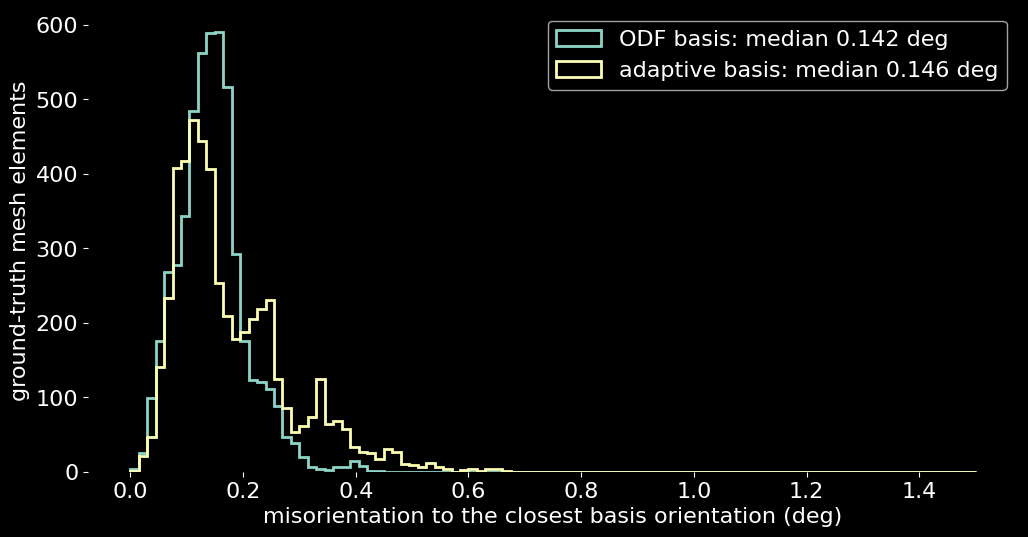

In [8]:
gt = io.read_ground_truth(SAMPLE)
idx = np.random.default_rng(0).choice(len(gt["orientation"]), 5000, replace=False)
q_gt = R.from_matrix(gt["orientation"][idx]).as_quat()
sym = symmetry_rotations(mat)
mis = {name: nearest_misorientation_deg(q_gt, R.from_matrix(u).as_quat(), sym)
       for name, u in [("ODF basis", basis), ("adaptive basis", np.load(paths.basis_path(SAMPLE)))]}

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
for name, m in mis.items():
    ax.hist(m, bins=100, range=(0, 1.5), histtype="step", lw=2, label=f"{name}: median {np.median(m):.3f} deg")
ax.set_xlabel("misorientation to the closest basis orientation (deg)")
ax.set_ylabel("ground-truth mesh elements")
ax.legend()
plot.despine(ax)
plt.show()

## Forward operator and data weights
The eta bins along the rotation axis get zero weight: bins 40-49 and 130-139, i.e. pyFAI azimuth of about -100..-80 and 80..100 deg. Peaks there cross the Ewald sphere at grazing angles and are poorly described by the model.

The data, the weights and the coefficients are NumPy arrays; the coefficients `x` (shape `(K, Ny, Nx)`) stay in host memory and are streamed through the GPU one orientation batch at a time.

In [9]:
max_gb = 1.0  # GPU memory budget for batching over orientations
# reserve_coefficient_arrays=0: the coefficients stay in host memory (streamed through the GPU)
op = SinglePhaseForwardOperator(cfg=cfg, material=mat, grid=grid, max_gb=max_gb, verbose=True, normalized=True,
                                reserve_coefficient_arrays=0, ctx=ctx, queue=queue)
Nx, Ny = op.Nx, op.Ny

b = arr.reshape(N_Omega, My, N_eta * N_theta).astype(np.float32)  # the data, (N_Omega, My, N_seg)
x = np.zeros(op.coeff_shape, dtype=np.float32)  # the coefficients, (K, Ny, Nx): x[k] is the image of orientation k

weights = np.ones((N_eta, N_theta), dtype=np.float32)  # one weight per (eta bin, ring), for every omega and translation
weights[40:50, :] = 0
weights[130:140, :] = 0
print(f"{100 * (weights == 0).mean():.1f}% of the data has zero weight")


=== OpenCL buffer allocation summary ===
coeffs_sino_C                 : shape=(360x103x260),    36.78 MB
_img_k                        : shape=(2548260),     9.72 MB
_basis_batch_kmax             : shape=(360x260x180x16),  1028.32 MB
---------------------------------------
TOTAL GPU buffer memory:  1074.82 MB


=== OpenCL buffer allocation summary ===
coeffs_sino_C                 : shape=(360x103x580),    82.04 MB
_img_k                        : shape=(5684580),    21.68 MB
---------------------------------------
TOTAL GPU buffer memory:   103.73 MB



Sparse PF matrix: 5422405 non-zeros (fill 0.225 %), 4 batches of up to 580; stored: both (81.1 MB), 0 generated in every call; scratch 0.0 MB; set up in 0.2 s
PF matrix: sparse, evaluated once
11.1% of the data has zero weight


## Reconstruction

In [10]:
niter = 200
huber_delta = 100.0  # transition between quadratic and linear data fit

norm_sq = estimate_L_power_streamed(op, niter=6, seed=0, verbose=1)
print(f"L = {1.1 * norm_sq:.4e}")

solver = FISTAHuber(op, prox_kind="nonneg", L=1.1 * norm_sq, huber_delta=huber_delta)
t0 = time.perf_counter()
x = solver.run(x, b, niter=niter, weights=weights, verbose=1, diagnostics_interval=10)
fista_time = time.perf_counter() - t0
print(f"FISTA finished in {fista_time:.0f} s")

[power 01] L_est=8.441652e+08  ||z||=1.022320e+10


[power 02] L_est=1.215520e+12  ||z||=2.050086e+12


[power 03] L_est=4.705824e+12  ||z||=4.994348e+12


[power 04] L_est=5.704999e+12  ||z||=5.869100e+12


[power 05] L_est=6.319878e+12  ||z||=6.434276e+12


...

[iter  160/200] obj=5.857442e+08  f=5.857442e+08  g=0.000000e+00  ||x||=7.686616e-02  ||grad||=5.821324e+09  tau=1.351e-13  beta=9.817e-01  (weighted)


[iter  170/200] obj=5.853423e+08  f=5.853423e+08  g=0.000000e+00  ||x||=7.902819e-02  ||grad||=5.827316e+09  tau=1.351e-13  beta=9.828e-01  (weighted)


[iter  180/200] obj=5.850202e+08  f=5.850202e+08  g=0.000000e+00  ||x||=8.112012e-02  ||grad||=5.828384e+09  tau=1.351e-13  beta=9.837e-01  (weighted)


[iter  190/200] obj=5.847381e+08  f=5.847381e+08  g=0.000000e+00  ||x||=8.315206e-02  ||grad||=5.830779e+09  tau=1.351e-13  beta=9.845e-01  (weighted)


[iter  200/200] obj=5.844781e+08  f=5.844781e+08  g=0.000000e+00  ||x||=8.512762e-02  ||grad||=5.834340e+09  tau=1.351e-13  beta=9.853e-01  (weighted)
FISTA finished in 22 s


## Data against prediction

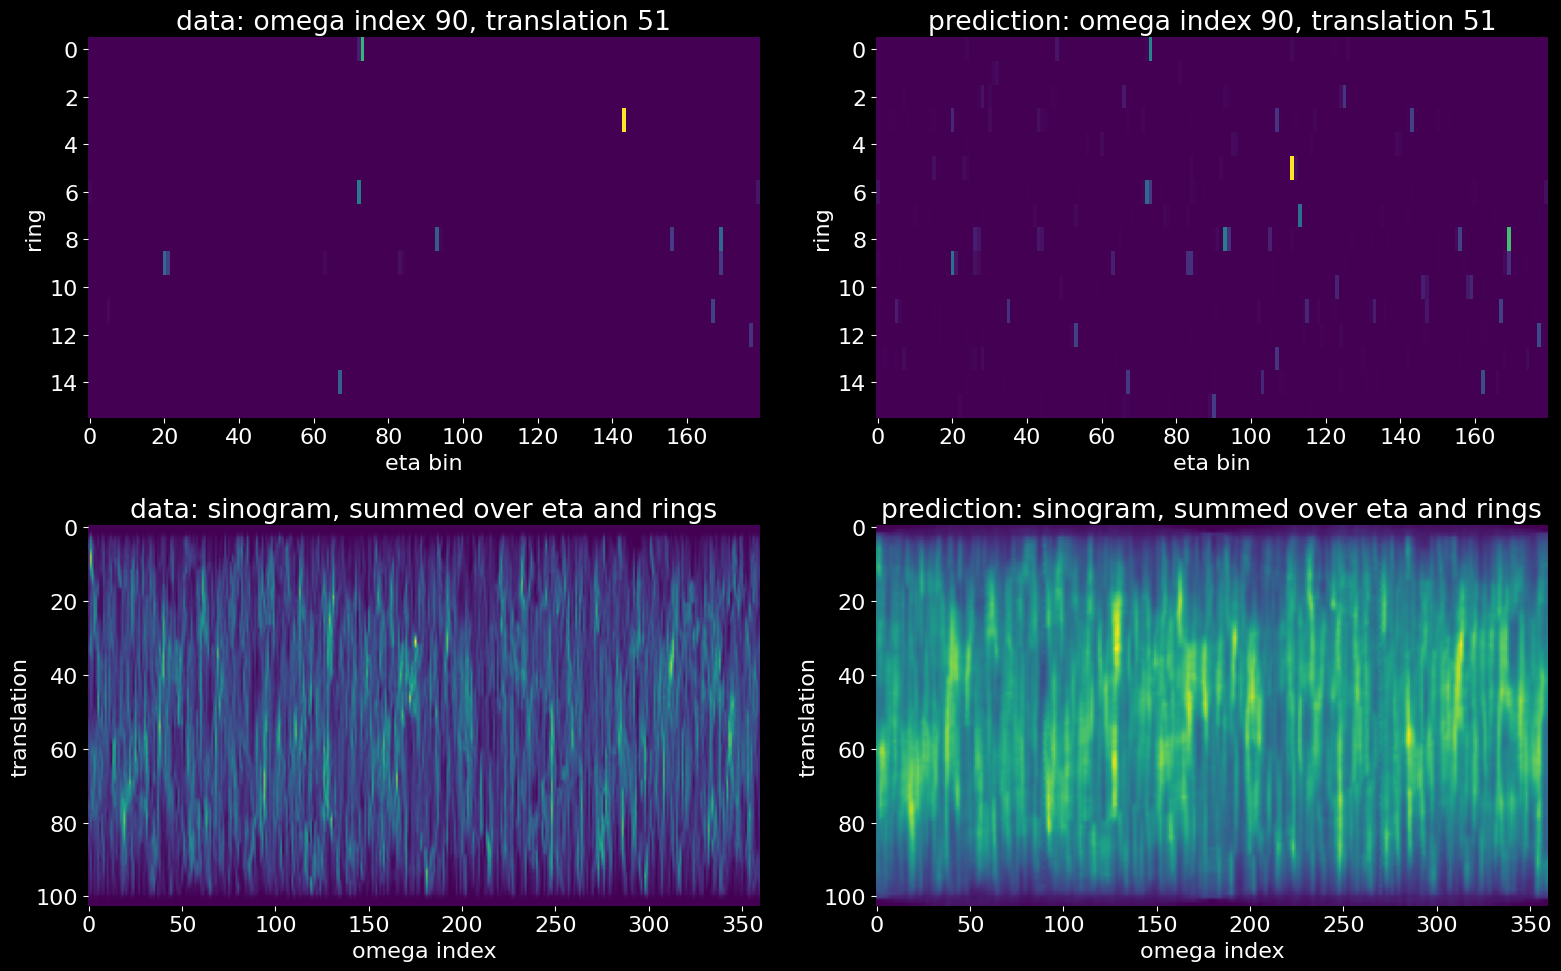

In [11]:
prediction = op.direct(x).reshape(N_Omega, My, N_eta, N_theta)

i_omega, i_trans = N_Omega // 4, My // 2
fig, ax = plt.subplots(2, 2, figsize=(16, 10))
for col, (a, title) in enumerate([(arr, "data"), (prediction, "prediction")]):
    ax[0, col].imshow(a[i_omega, i_trans].T, aspect="auto", interpolation="nearest")
    ax[0, col].set_title(f"{title}: omega index {i_omega}, translation {i_trans}")
    ax[0, col].set_xlabel("eta bin")
    ax[0, col].set_ylabel("ring")
    ax[1, col].imshow(a.sum(axis=(2, 3)).T, aspect="auto")
    ax[1, col].set_title(f"{title}: sinogram, summed over eta and rings")
    ax[1, col].set_xlabel("omega index")
    ax[1, col].set_ylabel("translation")
plot.despine(ax)
plt.tight_layout()
plt.show()

## Reconstructed map
Density (sum of coefficients) and the IPF colour of the dominant orientation per voxel.

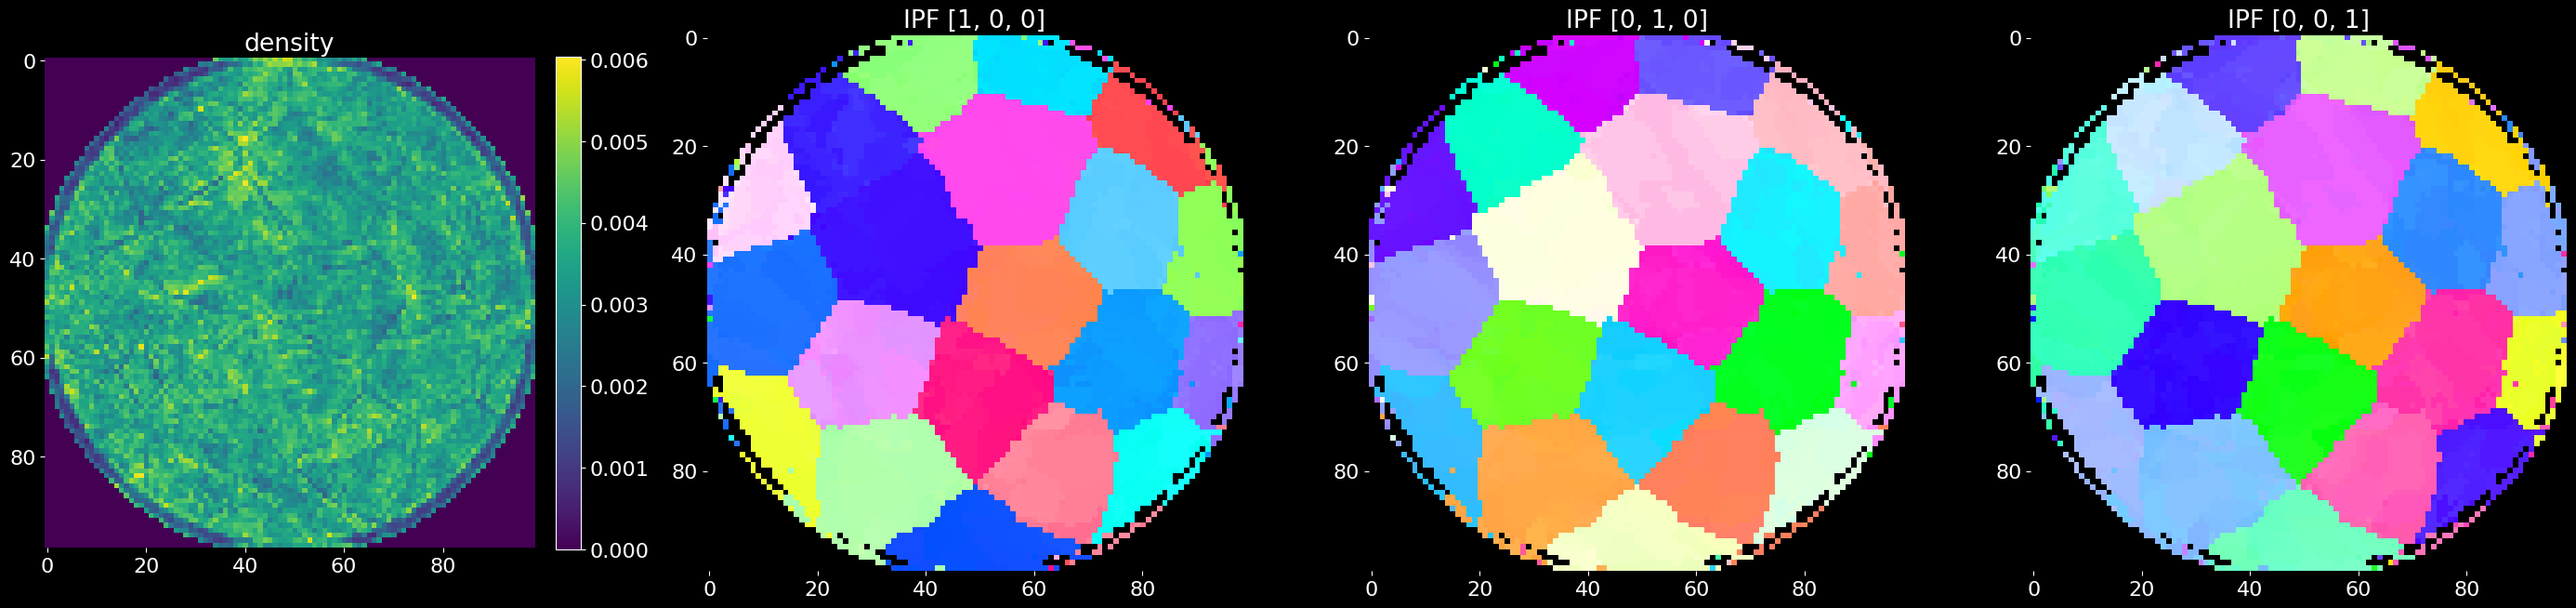

In [12]:
maps = coefficient_maps(x)  # per pixel, in the orientation of the ground-truth maps
grid_mats = R.concatenate(grid.rotations_at_level(0)).as_matrix()

density = maps.sum(axis=-1)
dominant = grid_mats[np.argmax(maps, axis=-1)]
sample_mask = density > 0.3 * np.percentile(density, 99)  # display only

fig, ax = plt.subplots(1, 4, figsize=(28, 7))
im = ax[0].imshow(density)
ax[0].set_title("density")
fig.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04)
for a, direction in zip(ax[1:], ([1, 0, 0], [0, 1, 0], [0, 0, 1])):
    ipfkey = orix_plot.IPFColorKeyTSL(symmetry.Oh, direction=Vector3d(direction))
    ori = Orientation.from_matrix(np.transpose(dominant.reshape(-1, 3, 3), (0, 2, 1)), symmetry.Oh)
    rgb = ipfkey.orientation2color(ori).reshape(*density.shape, 3)
    rgb[~sample_mask] = 0
    a.imshow(rgb)
    a.set_title(f"IPF {direction}")
plot.despine(ax)
plt.tight_layout()
plt.show()

## Save

In [13]:
out_path = os.path.join(paths.process_dir(SAMPLE), "reconstruction_odf.h5")
with h5py.File(out_path, "w") as f:
    f.create_dataset("grid_mats", data=grid_mats, compression="gzip")
    ds = f.create_dataset("coeffs", data=x, compression="gzip")
    ds.attrs["axes"] = "(K, Ny, Nx)"  # coeffs[k]: the image of orientation k (rows y, columns x)
    f.attrs["sample"] = SAMPLE
    f.attrs["grid"] = "odf"
    f.attrs["K"] = K
    f.attrs["sigma_deg"] = sigma_deg
    f.attrs["n_eta"] = N_eta
    f.attrs["huber_delta"] = huber_delta
    f.attrs["niter"] = niter
    f.attrs["Nx"] = Nx
    f.attrs["Ny"] = Ny
    f.attrs["fista_time_s"] = fista_time
    f.attrs["odf_time_s"] = odf_time
    f.attrs["odf_spacing_deg"] = ODF_SPACING_DEG
    f.attrs["odf_levels"] = ODF_LEVELS
    f.attrs["odf_keep_rel"] = KEEP_REL
    f.attrs["support_rel"] = SUPPORT_REL
    f.attrs["min_distance_deg"] = MIN_DISTANCE_DEG
print("saved", out_path)

saved /dtu-compute/msaca/adaptive_basis_simulations/processed/domains_mosaicity_1p0deg/reconstruction_odf.h5


## Check: reload and plot IPF-Z
Reloads the saved file and shows the dominant orientation per voxel as an IPF-Z map, to check
the saved reconstruction. The article's figures are made in
`visualization/<sample>/figure_panels.ipynb`.

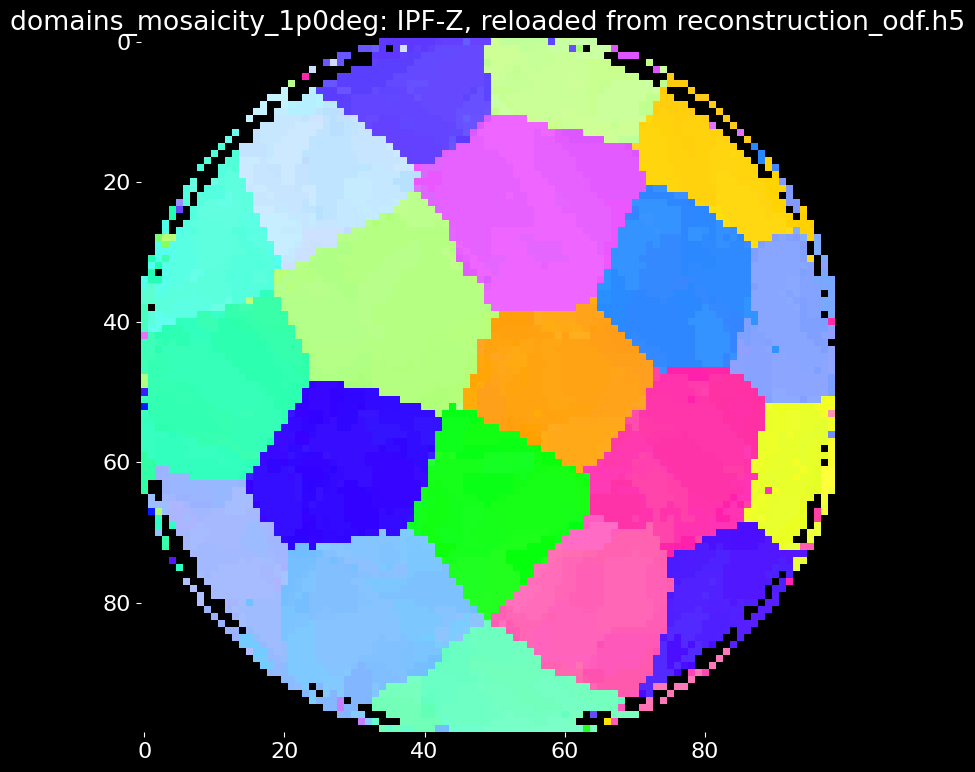

In [14]:
with h5py.File(out_path, "r") as f:
    maps_check = coefficient_maps(f["coeffs"][...])
    grid_mats_check = f["grid_mats"][...]

density_check = maps_check.sum(axis=-1)
dominant_check = grid_mats_check[np.argmax(maps_check, axis=-1)]
mask_check = density_check > 0.3 * np.percentile(density_check, 99)  # display only

ipfkey = orix_plot.IPFColorKeyTSL(symmetry.Oh, direction=Vector3d([0, 0, 1]))
ori = Orientation.from_matrix(np.transpose(dominant_check.reshape(-1, 3, 3), (0, 2, 1)), symmetry.Oh)
rgb = ipfkey.orientation2color(ori).reshape(*density_check.shape, 3)
rgb[~mask_check] = 0

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(rgb)
ax.set_title(f"{SAMPLE}: IPF-Z, reloaded from {os.path.basename(out_path)}")
plot.despine(ax)
plt.tight_layout()
plt.show()